## Data Cleaning

In [1]:
import pandas as pd
import numpy as np
import json

movies = pd.read_csv('Dataset/movies.csv')
credits = pd.read_csv('Dataset/credits.csv')
df = movies.merge(credits, on='title')
json_cols = ['genres', 'keywords', 'production_companies', 'production_countries', 'spoken_languages']
for col in json_cols:
    df[col] = df[col].apply(lambda x: json.loads(x) if pd.notnull(x) else [])
df['genres_list'] = df['genres'].apply(lambda x: [i['name'] for i in x] if x else [])
df['crew'] = df['crew'].apply(lambda x: json.loads(x) if pd.notnull(x) else [])
df['director'] = df['crew'].apply(
    lambda x: next((i['name'] for i in x if i['job'] == 'Director'), 'Unknown')
)
df['budget'] = df['budget'].replace(0, np.nan)
df['revenue'] = df['revenue'].replace(0, np.nan)
df = df.dropna(subset=['budget', 'revenue', 'vote_average'])

##  Exploratory Analysis & Visualizations

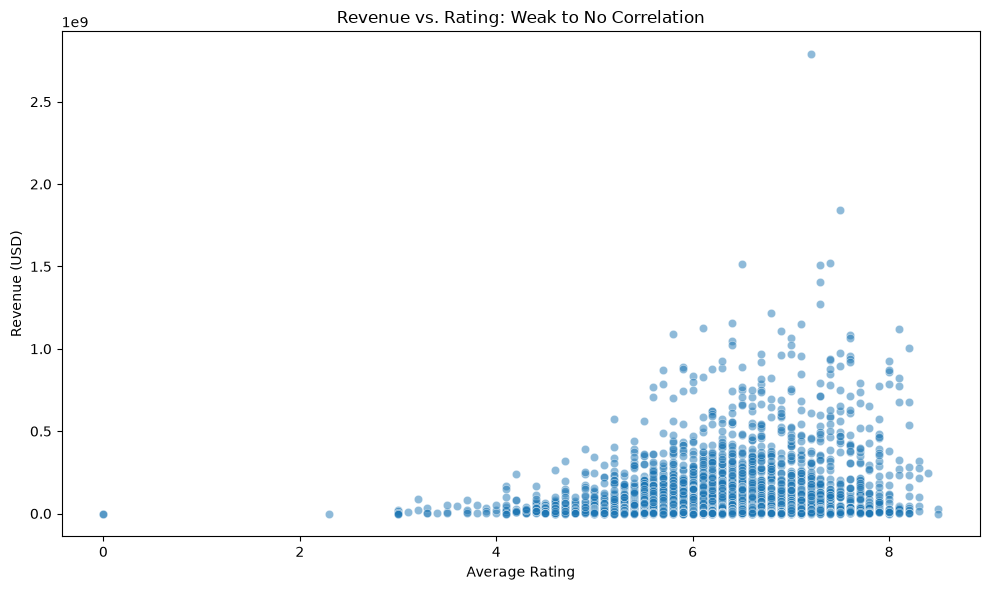

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x='vote_average', y='revenue', alpha=0.5, ax=ax)
ax.set_xlabel('Average Rating')
ax.set_ylabel('Revenue (USD)')
ax.set_title('Revenue vs. Rating: Weak to No Correlation')
plt.tight_layout()
plt.show()

## Budget, Revenue, and Profit

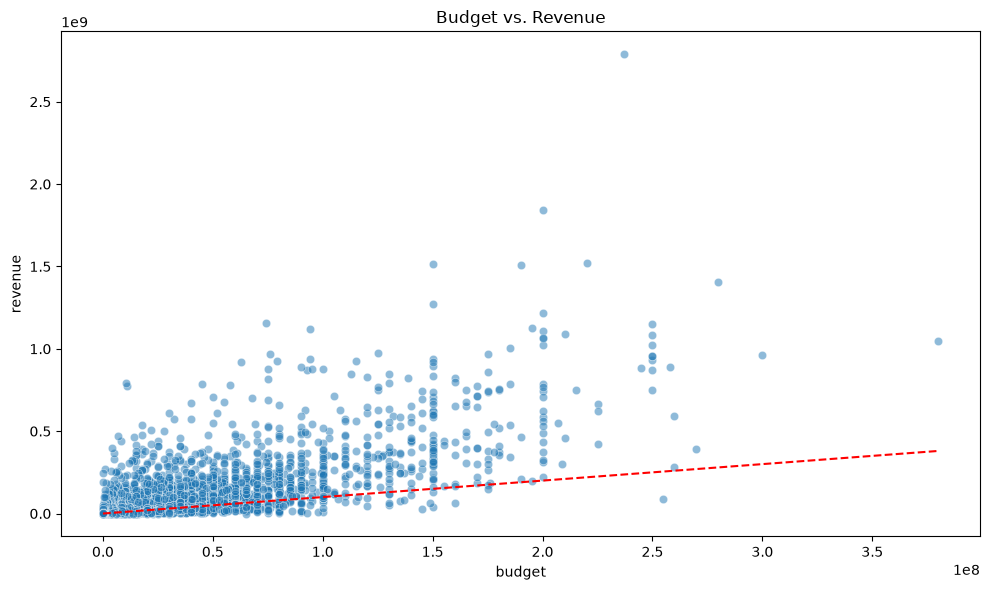

In [3]:
df['profit'] = df['revenue'] - df['budget']
df['profit_margin'] = df['profit'] / df['budget']

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x='budget', y='revenue', alpha=0.5, ax=ax)
ax.plot([0, df['budget'].max()], [0, df['budget'].max()], 'r--', label='Break-even')
ax.set_title('Budget vs. Revenue')
plt.tight_layout()
plt.show()

## Heatmap of Numeric Correlations

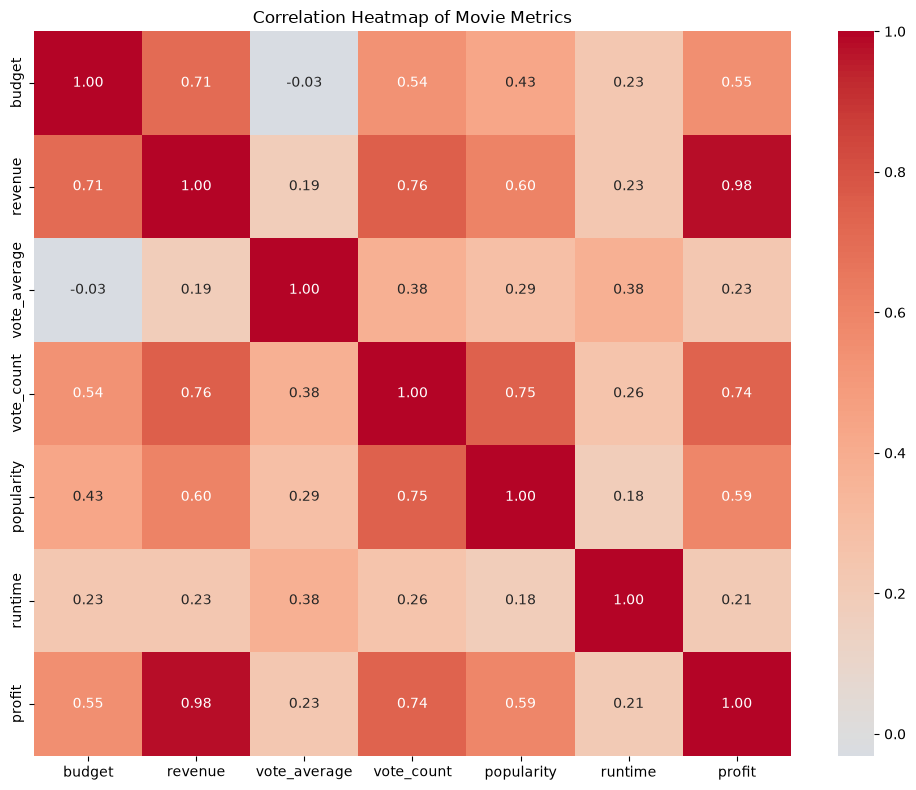

In [4]:
numeric_cols = ['budget', 'revenue', 'vote_average', 'vote_count', 'popularity', 'runtime', 'profit']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap of Movie Metrics')
plt.tight_layout()
plt.show()

## Genre Analysis

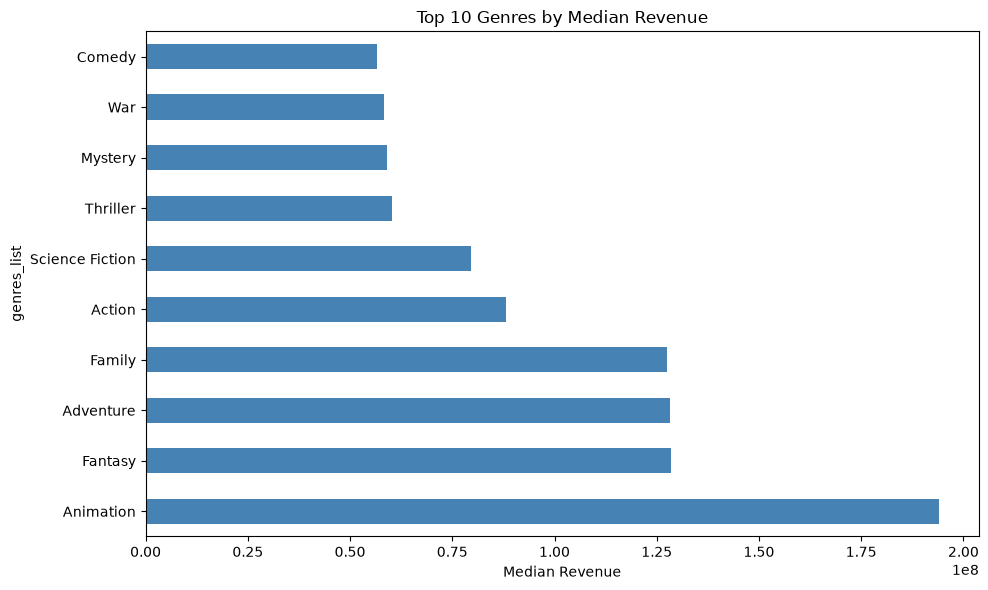

In [5]:
df_exploded = df.explode('genres_list')
genre_revenue = df_exploded.groupby('genres_list')['revenue'].median().sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(10, 6))
genre_revenue.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Median Revenue')
ax.set_title('Top 10 Genres by Median Revenue')
plt.tight_layout()
plt.show()

## Rating Distribution Over Time

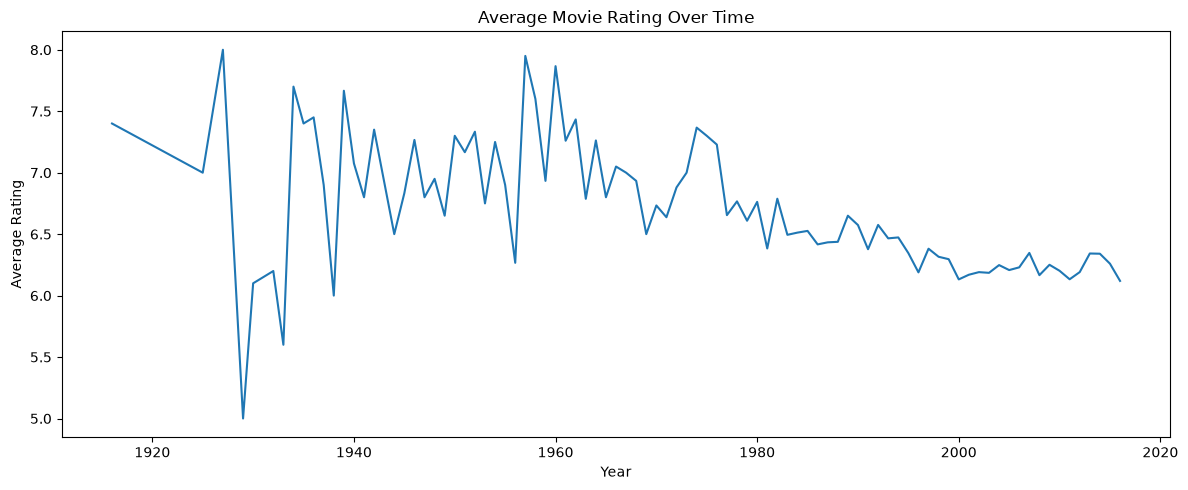

In [6]:
df['release_year'] = pd.to_datetime(df['release_date']).dt.year
yearly_rating = df.groupby('release_year')['vote_average'].mean()
fig, ax = plt.subplots(figsize=(12, 5))
yearly_rating.plot(ax=ax)
ax.set_xlabel('Year')
ax.set_ylabel('Average Rating')
ax.set_title('Average Movie Rating Over Time')
plt.tight_layout()
plt.show()